In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pyproj
import xesmf as xe

folder = '../data/NSIDC/sic/'
#source: https://noaadata.apps.nsidc.org/NOAA/G02202_V5/south/

In [63]:
ds_initial = xr.open_mfdataset(glob.glob(folder+'*.nc'),engine='h5netcdf')

In [68]:
sice_da = ds_initial.cdr_seaice_conc_monthly.load()

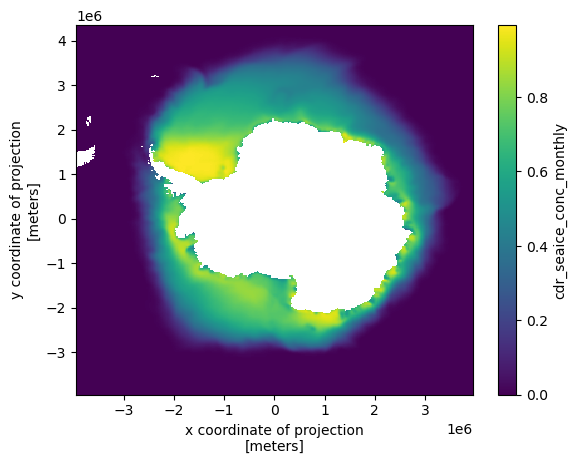

In [70]:
sice_da.mean('time').plot()

In [ ]:
xx, yy = np.meshgrid(ds_initial.x,ds_initial.y)

In [15]:
# Define the projection transformation
proj_from = pyproj.CRS("EPSG:3412")  # Source: Antarctic Polar Stereographic
proj_to = pyproj.CRS("EPSG:4326")  # Target: WGS84 (lat/lon)

# Create transformer
transformer = pyproj.Transformer.from_crs(proj_from, proj_to, always_xy=True)

# Apply transformation
lon, lat = transformer.transform(xx,yy)



In [72]:
# Add transformed coordinates to the dataset
sice_da = sice_da.assign_coords({'longitude':(("y","x"),lon),
                       'latitude':(("y","x"),lat)})

In [73]:
target_lon = np.linspace(lon.min(),lon.max(),len(sice_da.x))
target_lat = np.linspace(lat.min(),lat.max(),len(sice_da.y))

In [77]:
target_grid = xr.Dataset(
    {
        "latitude": (["latitude"], target_lat),
        "longitude": (["longitude"], target_lon),
    }
)

In [78]:
regridder = xe.Regridder(sice_da,target_grid,'bilinear')
sice = regridder(sice_da)#.mean(['latitude','longitude']).plot()

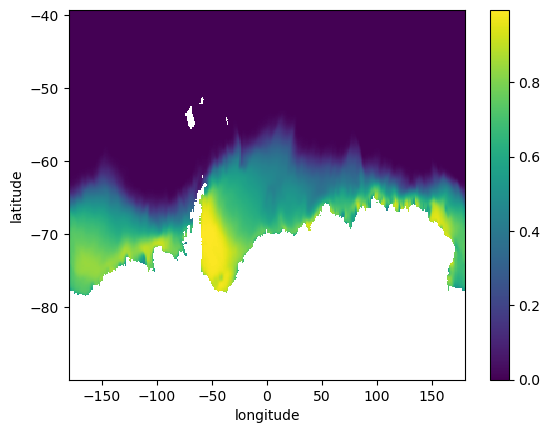

In [80]:
sice.mean('time').plot()

In [61]:
from stericheight.plotting_fns import PlottingFns
import cartopy.crs as ccrs
pfns = PlottingFns()

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object not 

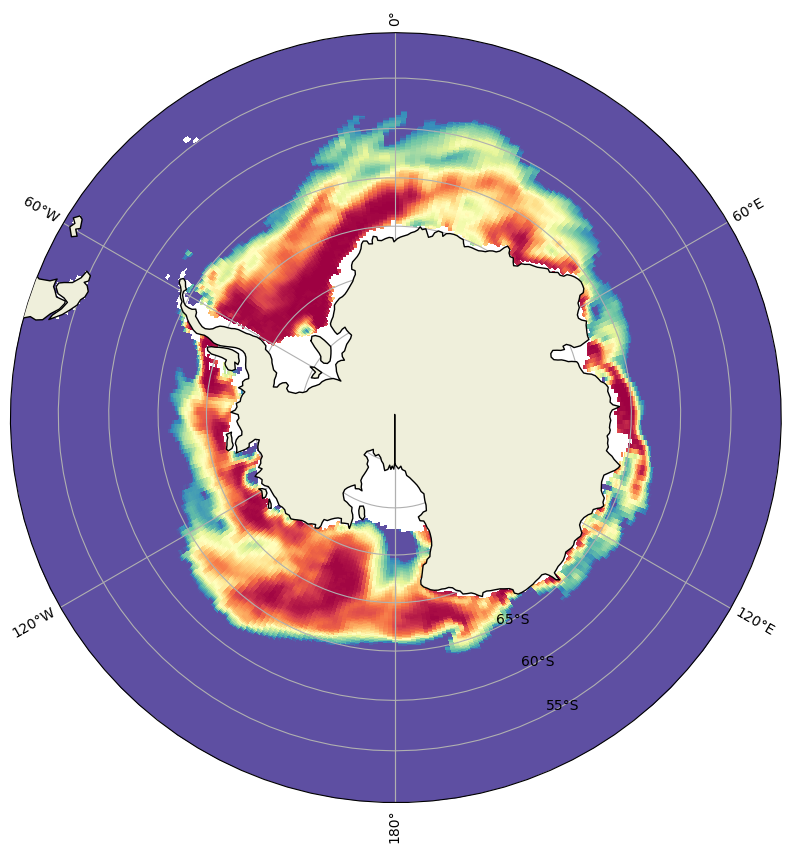

In [62]:
fig, ax = plt.subplots(figsize=(10,10),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,sice.cdr_seaice_conc_monthly.isel(time=23))

In [83]:
sice.to_netcdf('../data/NSIDC/sice_processed.nc')